# ２章２節 SARデータの地理座標投影

## 概要
SARデータに地理座標情報を付与するジオリファレンス処理を実装します。
SICDメタデータから抽出したGCP（地上基準点）を使用して、スラントレンジ座標系の画像を地理座標系（WGS84）に変換し、GeoTIFF形式で出力します。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | STRIX-B |
| データパス | /work/data/georeference/ |
| データ形式 | SICD/NITF (SLC形式、VV偏波) |
| 画像クレジット | © Synspective Inc.|

In [12]:
# 必要なライブラリのインポート
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal, osr
from sarpy.io.complex.sicd import SICDReader
from sarpy.geometry.geocoords import ecf_to_geodetic
from tqdm import tqdm
import japanize_matplotlib

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [13]:
# 入力データと出力先のパス設定
PATH_INPUT = '/work/data/georeference/'
PATH_OUTPUT = '/work/outputs/georeference/'

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

# SICDデータの読み込みと確認

In [14]:
# SICDファイルのパスを設定
IMG_PATH = os.path.join(PATH_INPUT, 'IMG-VV-STRIXB-20220829T142947Z-SLSLC-SICD.nitf')

# SICDファイルの読み込み
reader = SICDReader(IMG_PATH)

# 画像データの読み込み（複素数データ）
data = reader[0]

# 振幅情報の抽出
amplitude = np.abs(data)

print(f'画像サイズ: {amplitude.shape[0]} × {amplitude.shape[1]} ピクセル')
print(f'データ型: {amplitude.dtype}')

画像サイズ: 10193 × 12500 ピクセル
データ型: float32


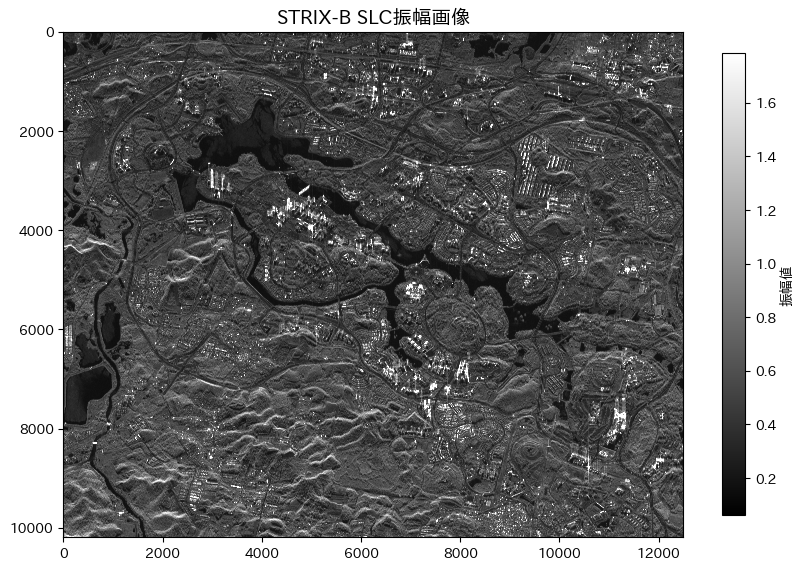

振幅値の範囲: 0.00 - 1108.34
2-98パーセンタイル: 0.06 - 1.78


In [15]:
# 可視化用のパーセンタイル値を計算（外れ値除外）
p2, p98 = np.percentile(amplitude, [2, 98])

# 振幅画像を可視化
plt.figure(figsize=(10, 10))
plt.imshow(amplitude, cmap='gray', vmin=p2, vmax=p98)
plt.title('STRIX-B SLC振幅画像', fontsize=14)
plt.colorbar(label='振幅値', shrink=0.6)
plt.show()

print(f'振幅値の範囲: {np.min(amplitude):.2f} - {np.max(amplitude):.2f}')
print(f'2-98パーセンタイル: {p2:.2f} - {p98:.2f}')

# メタデータの取得と位置情報の確認

In [16]:
# SICDファイルのメタ情報の取得
sicd_meta = reader.sicd_meta

# 画像の四隅の位置情報を取得
first_corner = sicd_meta.GeoData.ImageCorners[0]   # 左上
second_corner = sicd_meta.GeoData.ImageCorners[1]  # 右上
third_corner = sicd_meta.GeoData.ImageCorners[2]   # 右下
fourth_corner = sicd_meta.GeoData.ImageCorners[3]  # 左下

# 画像の中心点（SCP: Scene Center Point）の位置情報
scp_coordinates = sicd_meta.GeoData.SCP.LLH

# 位置情報の表示
print('=' * 60)
print('画像の位置情報（WGS84座標系）')
print('=' * 60)
print(f"画像の左上の位置情報: {first_corner}")
print(f"画像の右上の位置情報: {second_corner}")
print(f"画像の右下の位置情報: {third_corner}")
print(f"画像の左下の位置情報: {fourth_corner}")
print('-' * 60)
print(f"画像の中心点（SCP）の位置情報: {scp_coordinates}")
print('=' * 60)

画像の位置情報（WGS84座標系）
画像の左上の位置情報: LatLonCornerStringType(**{
 "Lat": 2.87581084708183,
 "Lon": 101.6582260625914,
 "index": "1:FRFC"
})
画像の右上の位置情報: LatLonCornerStringType(**{
 "Lat": 2.964484984952727,
 "Lon": 101.6408063576827,
 "index": "2:FRLC"
})
画像の右下の位置情報: LatLonCornerStringType(**{
 "Lat": 2.983037373913849,
 "Lon": 101.7323068424214,
 "index": "3:LRLC"
})
画像の左下の位置情報: LatLonCornerStringType(**{
 "Lat": 2.8943711432196,
 "Lon": 101.7497355640305,
 "index": "4:LRFC"
})
------------------------------------------------------------
画像の中心点（SCP）の位置情報: LatLonHAERestrictionType(**{
 "Lat": 2.929525146457647,
 "Lon": 101.6957338624693,
 "HAE": 73.69689840057129
})


# GCPを使用したジオリファレンス処理

In [17]:
def georeference_sar_image(amplitude, sicd_meta, output_path):
    """
    SICDメタデータを使用してSAR画像にジオリファレンスを適用する関数
    
    GCP（Ground Control Points）を使用して、スラントレンジ座標系の画像を
    地理座標系（WGS84）に変換し、GeoTIFF形式で保存します。
    
    Parameters:
    -----------
    amplitude : ndarray
        SAR画像の振幅データ（2次元配列）
    sicd_meta : SICDType
        SICDメタデータオブジェクト
    output_path : str
        出力GeoTIFFファイルの絶対パス
    
    Returns:
    --------
    None
        GeoTIFFファイルとして出力ディレクトリに保存
    """
    # 画像サイズの取得
    rows, cols = amplitude.shape
    
    # 画像の四隅とSCPの座標情報を取得
    corners = sicd_meta.GeoData.ImageCorners
    scp = sicd_meta.GeoData.SCP.LLH
    scp_pixel = sicd_meta.ImageData.SCPPixel
    
    # 空間参照系の設定（WGS84: EPSG:4326）
    srs = osr.SpatialReference()
    srs.ImportFromEPSG(4326)
    
    # GCP（地上基準点）の設定
    # 四隅 + 中心点の5点を使用
    gcps = [
        gdal.GCP(corners[0].Lon, corners[0].Lat, 0, 0, 0),                    # 左上
        gdal.GCP(corners[1].Lon, corners[1].Lat, 0, cols-1, 0),               # 右上
        gdal.GCP(corners[2].Lon, corners[2].Lat, 0, cols-1, rows-1),          # 右下
        gdal.GCP(corners[3].Lon, corners[3].Lat, 0, 0, rows-1),               # 左下
        gdal.GCP(scp.Lon, scp.Lat, 0, scp_pixel.Col, scp_pixel.Row)          # 中心点
    ]
    
    # GeoTIFFドライバで出力ファイルを作成
    driver = gdal.GetDriverByName("GTiff")
    dst_ds = driver.Create(output_path, cols, rows, 1, gdal.GDT_Float32)
    
    # GCPと投影情報を設定
    dst_ds.SetGCPs(gcps, srs.ExportToWkt())
    
    # GCPからジオトランスフォームを計算
    geotransform = gdal.GCPsToGeoTransform(gcps)
    if geotransform:
        dst_ds.SetGeoTransform(geotransform)
    
    # 投影情報を設定
    dst_ds.SetProjection(srs.ExportToWkt())
    
    # ラスターデータを書き込み
    dst_ds.GetRasterBand(1).WriteArray(amplitude)
    
    # ファイルをクローズして保存
    dst_ds = None
    
    print(f'ジオリファレンス処理完了: {output_path}')

In [18]:
# 出力ファイルパスの設定
OUTPUT_GEOTIFF = os.path.join(PATH_OUTPUT, 'georeferenced_image.tif')

# ジオリファレンス処理の実行
georeference_sar_image(amplitude, sicd_meta, OUTPUT_GEOTIFF)

print(f'\n出力ファイル: {OUTPUT_GEOTIFF}')
print(f'ファイルサイズ: {os.path.getsize(OUTPUT_GEOTIFF) / 1024 / 1024:.2f} MB')

ジオリファレンス処理完了: /work/outputs/georeference/georeferenced_image.tif

出力ファイル: /work/outputs/georeference/georeferenced_image.tif
ファイルサイズ: 486.10 MB


Warning 1: georeferenced_image.tif: GCPs previously set are going to be cleared due to the setting of a geotransform.
